# Modelo SIR com agentes

## Importando bibliotecas e definindo funções

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import agent_based_model as abm

In [91]:
def rmsd_func(a1, a2):
    rmsd = np.sqrt(np.mean((a1 - a2)**2))
    return rmsd

def identify_ext(infected_serie):
    if infected_serie[-1] == 0:
        return 1
    else:
        return 0

def rmsd_fun_advance(y1, y2, x1 = False, x2 = False, mode = 'simple', start_at_matching = False, force_matching = False):

    if np.all(np.isnan(y1)) or np.all(np.isnan(y2)):

        print('All NaN')
        return np.nan, np.nan, np.nan

    x1_interval = x1[-1] - x1[0]
    x2_interval = x2[-1] - x2[0]

    # The serie with smaller interval will dictate the time instante to evaluate RMSD
    if x1_interval > x2_interval:
        broader_x = x1
        narrower_x = x2
        y_to_cut = y1
        y_to_maintain = y2
    else:
        broader_x = x2
        narrower_x = x1
        y_to_cut = y2
        y_to_maintain = y1

    
    match mode:

        case 'simple':
            
            return rmsd_func(y1, y2)

        case 'start_at_matching_x':

            match_xdelta_condition = np.isin(broader_x.round(3), narrower_x.round(3))
            y_cut = y_to_cut[match_xdelta_condition]
            x_cut = broader_x[match_xdelta_condition]

        case 'shift_to_match_y':

            min_y = min(y_to_maintain)

            #yi = 
            
            #y_dif = y_to_cut - min_y
            #y_dif == 0

            if np.all(y_to_cut < min_y):

                print('All small')
                return np.nan, np.nan, np.nan

            xi = broader_x[y_to_cut >= min_y][0]

            time_cut_condition = broader_x >= xi

            broader_x_cut = broader_x[time_cut_condition] - xi
            match_xdelta_condition = np.isin(broader_x_cut.round(3), (narrower_x - min(narrower_x)).round(3))

            y_cut = y_to_cut[time_cut_condition][match_xdelta_condition]
            x_cut = broader_x_cut[match_xdelta_condition] + xi


    if len(y_cut) != len(y_to_maintain):

        print(xi)
        print(len(y_cut) - len(y_to_maintain))        
        
        return np.nan, np.nan, np.nan

    
    rmsd = rmsd_func(y_cut, y_to_maintain)

    return rmsd, y_cut, x_cut
        



## Boarding School

### Importando dados

In [2]:
boarding_school = pd.read_csv('boarding_school_data.csv')

In [187]:
boarding_school = pd.DataFrame({'Day': np.arange(1,15),
                                'Infected number': [3, 8, 28, 75, 221, 291, 255, 235, 190, 126, 70, 28, 12, 5]})

In [188]:
#boarding_school['Day'] = boarding_school['Day'] - 1
boarding_school

,Day,Infected number
0,1,3
1,2,8
2,3,28
3,4,75
4,5,221
5,6,291
6,7,255
7,8,235
8,9,190
9,10,126


### Simular com agentes

In [4]:
# Condições iniciais
N, S_i = 763, 762
I_i = N - S_i
R_i = 0
init_conditions = np.array([S_i, I_i, R_i])

# Parâmetros epidêmicos
beta, gamma = np.arange(1, 2.5, 0.01), np.arange(0.01, 1, 0.01)

dt, tf = 0.1, 20

sample_size = 50

params = np.array([[b, g, n] 
                   for b in beta for g in gamma for n in range(sample_size)],
                    dtype = np.float64)

# Rodar simulações
sim = abm.many_sims_numba('SIR_numba', init_conditions, params, dt, tf)


  0%|          | 0/742500 [00:00<?, ?it/s]

### Calcular médias das simulações

In [ ]:
ext_limit = 50 # Indice do valor de infectados para verificação de extinção
ext = np.apply_along_axis(identify_ext, 1, sim[2][:,:ext_limit])
ext_reshaped = ext.reshape(int(len(ext)/sample_size), sample_size)
ext_sum = np.sum(ext_reshaped, axis = 1)

S_reshaped = sim[1].reshape(int(len(sim[1])/sample_size), sample_size, int(tf/dt + 1))
I_reshaped = sim[2].reshape(int(len(sim[2])/sample_size), sample_size, int(tf/dt + 1))
R_reshaped = sim[3].reshape(int(len(sim[3])/sample_size), sample_size, int(tf/dt + 1))

sims_mean = [sim[0][::sample_size], [], [], []]
sims_std = [sim[0][::sample_size], [], [], []]
for i in range(int(len(ext)/sample_size)):
    S_mean = np.mean(S_reshaped[i][ext_reshaped[i] == 0], axis=0)
    I_mean = np.mean(I_reshaped[i][ext_reshaped[i] == 0], axis=0)
    R_mean = np.mean(R_reshaped[i][ext_reshaped[i] == 0], axis=0)

    S_std = np.std(S_reshaped[i][ext_reshaped[i] == 0], axis=0)
    I_std = np.std(I_reshaped[i][ext_reshaped[i] == 0], axis=0)
    R_std = np.std(R_reshaped[i][ext_reshaped[i] == 0], axis=0)

    sims_mean[1].append(S_mean); sims_mean[2].append(I_mean); sims_mean[3].append(R_mean)
    sims_std[1].append(S_std); sims_std[2].append(I_std); sims_std[3].append(R_std)

#sims_mean = sim[0][::sample_size], np.mean(S_reshaped, axis=1), np.mean(I_reshaped, axis=1), np.mean(R_reshaped, axis=1)
#sims_std = sim[0][::sample_size], np.std(S_reshaped, axis=1), np.std(I_reshaped, axis=1), np.std(R_reshaped, axis=1)


### Calcular RMSD

In [50]:
tt = (np.arange(len(sims_mean[2][0]))*dt).round(1)
error = []
cut_sim = []
cut_std = []
br_x = []

for i in range(len(sims_mean[2])):
    e, y_c = rmsd_fun_advance(sims_mean[2][i], boarding_school['Infected number'].values, 
                                    x1 = tt, x2 = boarding_school['Day'].values, 
                                    mode = 'start_at_matching_x')
    
    error.append(e)
    cut_sim.append(y_c)


In [51]:
print(error)
print(np.argsort(error))
print(np.sort(error))

[np.float64(413.371744110034), np.float64(392.31855387969347), np.float64(367.01656714551154), np.float64(351.6471453846069), np.float64(322.2329189211716), np.float64(306.43710138882295), np.float64(304.75198186729943), np.float64(284.25685062650496), np.float64(271.4114314867311), np.float64(252.3562029172781), np.float64(250.32684454634324), np.float64(242.39223402860284), np.float64(221.53929661558996), np.float64(219.5989907198438), np.float64(201.10096249535619), np.float64(196.45786700992917), np.float64(194.29570008181162), np.float64(198.35539749903165), np.float64(182.13542919460025), np.float64(179.48218488361996), np.float64(169.7333279048986), np.float64(167.44009758208202), np.float64(155.75109688597595), np.float64(157.73348580641607), np.float64(156.2118665989045), np.float64(153.28050089085946), np.float64(144.16737218596833), np.float64(141.24925428545805), np.float64(142.68393193168907), np.float64(140.6125183399055), np.float64(138.78576899132514), np.float64(131.90

### Criar gráfico

[1.7691 0.4448 0.    ]
[0.06213043 0.02151651 0.        ]
[1.8  0.45 0.  ]


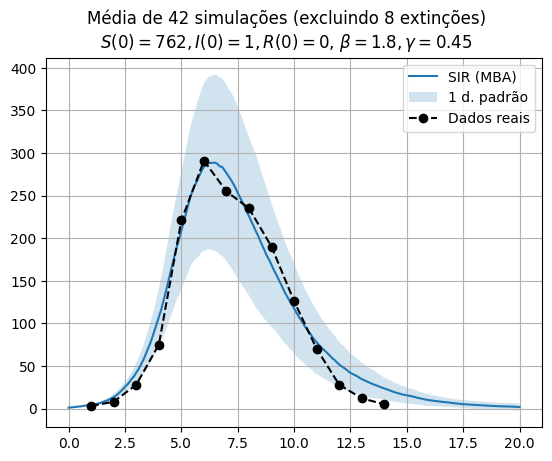

In [52]:
ind = np.argsort(error)

print(np.mean(sims_mean[0][ind][:100], axis=0))
print(np.std(sims_mean[0][ind][:100], axis=0))

fig, ax = plt.subplots()

initial_conditions_label = r'$S(0) = {}, I(0) = {}, R(0) = {}$'.format(S_i, I_i, R_i)
parameters_label = r'$\beta = {}, \gamma = {}$'.format(*sims_mean[0][ind][0].round(2))
fig.suptitle('Média de {} simulações (excluindo {} extinções)'.format(sample_size - ext_sum[ind][0], ext_sum[ind][0])+'\n'+initial_conditions_label+', '+parameters_label)

for i in range(1):
    #ax.plot(boarding_school['Day'], cut_sim[ind[i]], label='SIR (MBA)')
    ax.plot(np.arange(len(sims_mean[2][ind[i]]))*dt, sims_mean[2][ind[i]], label='SIR (MBA)')
    #mean = cut_sim[ind[i]]
    #std = cut_std[ind[i]]
    #ax.fill_between(boarding_school['Day'], mean-std, mean+std, alpha=0.2)
    mean = sims_mean[2][ind[i]]
    std = sims_std[2][ind[i]]
    ax.fill_between(np.arange(len(sims_mean[2][ind[i]]))*dt, mean-std, mean+std, alpha=0.2, label='1 d. padrão')

    #print(cut_sim[ind[i]])
    print(sims_mean[0][ind[i]])

ax.plot(boarding_school['Day'], boarding_school['Infected number'], 'o--', c='k', label='Dados reais')
ax.grid()
ax.legend()

In [23]:
1.8/763

0.00235910878112713

## Diamond Princess

De acordo com este [artigo](https://pmc.ncbi.nlm.nih.gov/articles/PMC7107563/) o número de pessoas no Diamond Princess era 3700.

Os dados de valores casos e mortes confirmadas foram extraidos dos [relatórios da OMS](https://www.who.int/emergencies/diseases/novel-coronavirus-2019/situation-reports/situation-reports-archive). Perceba que existem quedas no número de casos acumulados, isso se deve a correções realizadas pela OMS.

In [7]:
diamond_princess = pd.read_csv('diamond_princess.csv')

In [8]:
diamond_princess

,date,time_delta,confirmed_cases,confirmed_deaths
0,2020-02-05,0,10,0
1,2020-02-06,1,20,0
2,2020-02-07,2,61,0
3,2020-02-08,3,64,0
4,2020-02-09,4,64,0
5,2020-02-10,5,70,0
6,2020-02-11,6,135,0
7,2020-02-12,7,175,0
8,2020-02-13,8,174,0
9,2020-02-14,9,218,0


In [77]:
# Condições iniciais
N, S_i = 3700, 3699
I_i = N - S_i
R_i = 0
init_conditions = np.array([S_i, I_i, R_i])

# Parâmetros epidêmicos
beta, gamma = np.arange(1.0, 2.5, 0.02), np.arange(1.0, 2, 0.02)

dt, tf = 0.1, 60

sample_size = 100

params = np.array([[b, g, n] 
                   for b in beta for g in gamma for n in range(sample_size)],
                    dtype = np.float64)

# Rodar simulações
sim = abm.many_sims_numba('SIR_numba', init_conditions, params, dt, tf)


  0%|          | 0/375000 [00:00<?, ?it/s]

In [161]:
ext_limit = 100 # Indice do valor de infectados para verificação de extinção
ext = np.apply_along_axis(identify_ext, 1, sim[2][:,:ext_limit])
ext_reshaped = ext.reshape(int(len(ext)/sample_size), sample_size)
ext_sum = np.sum(ext_reshaped, axis = 1)

S_reshaped = sim[1].reshape(int(len(sim[1])/sample_size), sample_size, int(tf/dt + 1))
I_reshaped = sim[2].reshape(int(len(sim[2])/sample_size), sample_size, int(tf/dt + 1))
R_reshaped = sim[3].reshape(int(len(sim[3])/sample_size), sample_size, int(tf/dt + 1))

sims_mean = [sim[0][::sample_size], [], [], []]
sims_std = [sim[0][::sample_size], [], [], []]
for i in range(int(len(ext)/sample_size)):
    S_mean = np.mean(S_reshaped[i][ext_reshaped[i] == 0], axis=0)
    I_mean = np.mean(I_reshaped[i][ext_reshaped[i] == 0], axis=0)
    R_mean = np.mean(R_reshaped[i][ext_reshaped[i] == 0], axis=0)

    S_std = np.std(S_reshaped[i][ext_reshaped[i] == 0], axis=0)
    I_std = np.std(I_reshaped[i][ext_reshaped[i] == 0], axis=0)
    R_std = np.std(R_reshaped[i][ext_reshaped[i] == 0], axis=0)

    sims_mean[1].append(S_mean); sims_mean[2].append(I_mean); sims_mean[3].append(R_mean)
    sims_std[1].append(S_std); sims_std[2].append(I_std); sims_std[3].append(R_std)

#sims_mean = sim[0][::sample_size], np.mean(S_reshaped, axis=1), np.mean(I_reshaped, axis=1), np.mean(R_reshaped, axis=1)
#sims_std = sim[0][::sample_size], np.std(S_reshaped, axis=1), np.std(I_reshaped, axis=1), np.std(R_reshaped, axis=1)


In [162]:
I_cum_mean = N-np.array(sims_mean[1])
I_cum_std = np.array(sims_std[1])

In [163]:
tt = (np.arange(len(sims_mean[2][0]))*dt).round(1)
error = []
cut_sim = []
cut_std = []
cut_t = []

for i in range(len(I_cum_mean)):
    e, y_c, t_c = rmsd_fun_advance(I_cum_mean[i], diamond_princess['confirmed_cases'].values, 
                                    x1 = tt, x2 = diamond_princess['time_delta'].values, 
                                    mode = 'shift_to_match_y')
    
    error.append(e)
    cut_sim.append(y_c)
    cut_t.append(t_c)
    cut_std.append(I_cum_std[i][np.isin(tt, t_c)])


All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN
All NaN


[1.7976 1.5972 0.    ]
[0.20375044 0.19308071 0.        ]
[ 10.41666667  22.16666667  43.66666667  67.25        89.66666667
 116.75       155.91666667 196.41666667 242.         299.58333333
 346.5        386.91666667 437.16666667 483.75       526.16666667
 563.08333333 591.66666667 614.33333333 633.33333333 646.58333333
 657.         665.58333333 671.75       676.33333333 679.33333333
 681.75       682.41666667 683.41666667 683.66666667 683.66666667
 683.66666667 683.66666667 683.66666667 683.66666667 683.66666667
 683.66666667 683.66666667 683.66666667 683.66666667 683.66666667
 683.66666667 683.66666667 683.66666667]
[ 1.2  1.3  1.4  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5
  2.6  2.7  2.8  2.9  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9
  4.   4.1  4.2  4.3  4.4  4.5  4.6  4.7  4.8  4.9  5.   5.1  5.2  5.3
  5.4  5.5  5.6  5.7  5.8  5.9  6.   6.1  6.2  6.3  6.4  6.5  6.6  6.7
  6.8  6.9  7.   7.1  7.2  7.3  7.4  7.5  7.6  7.7  7.8  7.9  8.   8.1
  8.2  8.3  8.4  8

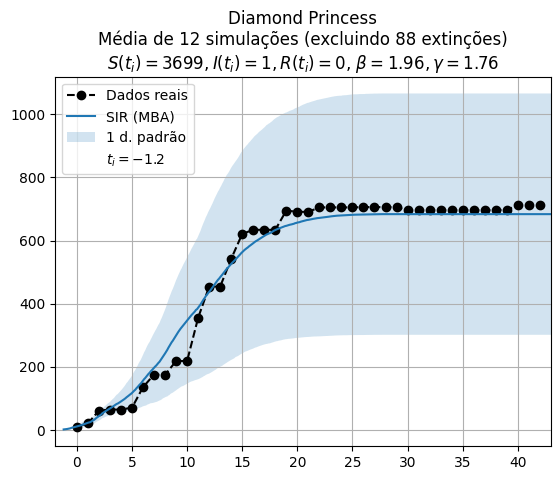

In [186]:
ind = np.argsort(error)

print(np.mean(sims_mean[0][ind][:50], axis=0))
print(np.std(sims_mean[0][ind][:50], axis=0))

fig, ax = plt.subplots()

initial_conditions_label = r'$S(t_{{i}}) = {}, I(t_{{i}}) = {}, R(t_{{i}}) = {}$'.format(S_i, I_i, R_i)
parameters_label = r'$\beta = {}, \gamma = {}$'.format(*sims_mean[0][ind][0].round(2))
ax.set_title('Diamond Princess'+'\n'+'Média de {} simulações (excluindo {} extinções)'.format(sample_size - ext_sum[ind][0], ext_sum[ind][0])+'\n'+initial_conditions_label+', '+parameters_label)

ax.plot(diamond_princess['time_delta'], diamond_princess['confirmed_cases'], 'o--', c='k', label='Dados reais')

for i in range(1):

    #ax.plot(diamond_princess['time_delta'], cut_sim[ind[i]], 'o-', label='SIR (MBA)')
    #mean = cut_sim[ind[i]]
    #std = cut_std[ind[i]]
    #ax.fill_between(diamond_princess['time_delta'], mean-std, mean+std, alpha=0.2, label='1 d. padrão')

    ti = cut_t[ind[i]][0]
    ax.plot(tt - ti, I_cum_mean[ind[i]], label='SIR (MBA)')
    mean = I_cum_mean[ind[i]]
    std = I_cum_std[ind[i]]
    ax.fill_between(tt - ti, mean - std, mean + std, alpha=0.2, label='1 d. padrão')
    ax.plot([],[], ' ', label = r'$t_{{i}} = {}$'.format(-1*ti), c='y')

    print(cut_sim[ind[i]])
    print(tt[I_cum_mean[ind[i]] >= 10])
    print(sims_mean[0][ind[i]])
    print(std)

ax.set(xlim=(-2, 43))
ax.grid()
ax.legend()

In [ ]:
def save_sim(sim, name, file_format):

    match file_format:
        case 'npz':
            np.savez_compressed(name,
                    parameters = sim[0], susceptible = sim[1],
                    infected = sim[2], removed = sim[3])

        case 'csv':
            df = pd.DataFrame({'beta': sim[0][:,0], 'gamma': sim[0][:,1], 'n_sample': sim[0][:,2],
                               'suceptible': sim[1].tolist(), 'infected': sim[2].tolist(),
                               'removed': sim[3].tolist()})
            df.to_csv('{}.csv'.format(name), index=False)


In [80]:
save_sim(sim=sim, name='sir_agents_dt01_21ago2026_diamondprincess', file_format='npz')